In [23]:
import mysql.connector 
import pandas as pd
import matplotlib.pyplot as plt


In [24]:
conn=mysql.connector.connect(
    host="localhost",
    user="root",
    password="salam",
    database="chocolate_db"
)

In [25]:
cursor=conn.cursor()


In [26]:
df=pd.read_sql("select * from chocolatesales",conn)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17804\4202872234.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql("select * from chocolatesales",conn)


In [27]:
df.isnull().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [28]:
df.describe()

,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


In [29]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.dtypes

Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                      str
Boxes Shipped             int64
dtype: object

In [52]:
df["Date"]=pd.to_datetime(df["Date"],format="%d/%m/%Y")
df.dtypes

Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
dtype: object

In [48]:
df["Amount"]=df["Amount"].str.replace("$","")
df["Amount"]=pd.to_numeric(df["Amount"])

In [51]:
df.dtypes

Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
dtype: object

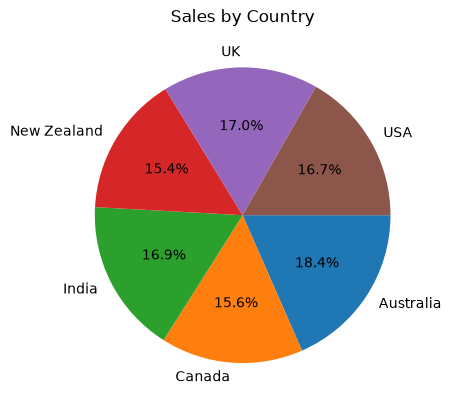

In [82]:
Sales_by_country=df.groupby("Country")["Amount"].sum()
plt.pie(Sales_by_country,labels=Sales_by_country.index,autopct="%1.1f%%",counterclock=False)
plt.title("Sales by Country")
plt.show()

In [75]:
df["Product"].value_counts()

Product
50% Dark Bites          180
Eclairs                 180
Smooth Sliky Salty      177
White Choc              174
Drinking Coco           168
Spicy Special Slims     162
Organic Choco Syrup     156
85% Dark Bars           150
After Nines             150
Fruit & Nut Bars        150
Peanut Butter Cubes     147
99% Dark & Pure         147
Milk Bars               147
Almond Choco            144
Raspberry Choco         144
Orange Choco            141
Mint Chip Choco         135
Manuka Honey Choco      135
Caramel Stuffed Bars    129
70% Dark Bites          126
Baker's Choco Chips     123
Choco Coated Almonds    117
Name: count, dtype: int64

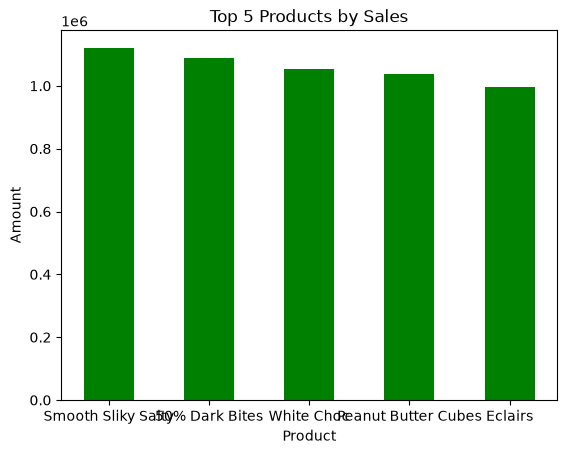

In [83]:
# Top 5 product by sales
top_products=df.groupby("Product")["Amount"].sum().sort_values(ascending=False).head(5)
plt.bar(top_products.index,top_products.values,color="green",width=0.5)
plt.title("Top 5 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Amount")
plt.show()

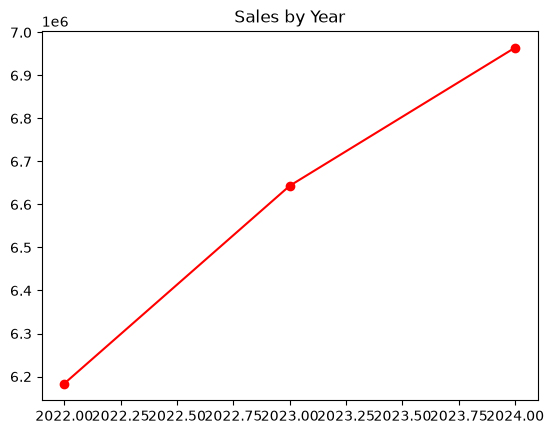

In [88]:
# Sales by year
sales_by_year=df.groupby(df["Date"].dt.year)["Amount"].sum()
plt.plot(sales_by_year.index,sales_by_year.values,color="red",marker="o")
plt.title("Sales by Year")
plt.show()

In [89]:
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.00,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.00,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.00,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.00,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.00,184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,2024-05-17,5303.58,354
3278,Jehu Rudeforth,USA,White Choc,2024-06-07,7339.32,121
3279,Ches Bonnell,Canada,Organic Choco Syrup,2024-07-26,616.09,238
3280,Dotty Strutley,India,Eclairs,2024-07-28,2504.62,397
